##  Feature Detection and Description

Line detection in python with OpenCV | Houghline method

In [1]:
# Python program to illustrate HoughLine
# method for line detection
import cv2
import numpy as np

# Reading the required image in
# which operations are to be done.
# Make sure that the image is in the same
# directory in which this python program is
img = cv2.imread('images/image.jpg')

# Convert the img to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply edge detection method on the image
edges = cv2.Canny(gray, 50, 150, apertureSize=3)

# This returns an array of r and theta values
lines = cv2.HoughLines(edges, 1, np.pi/180, 200)

# The below for loop runs till r and theta values
# are in the range of the 2d array
for r_theta in lines:
    arr = np.array(r_theta[0], dtype=np.float64)
    r, theta = arr
    # Stores the value of cos(theta) in a
    a = np.cos(theta)

    # Stores the value of sin(theta) in b
    b = np.sin(theta)

    # x0 stores the value rcos(theta)
    x0 = a*r

    # y0 stores the value rsin(theta)
    y0 = b*r

    # x1 stores the rounded off value of (rcos(theta)-1000sin(theta))
    x1 = int(x0 + 1000*(-b))

    # y1 stores the rounded off value of (rsin(theta)+1000cos(theta))
    y1 = int(y0 + 1000*(a))

    # x2 stores the rounded off value of (rcos(theta)+1000sin(theta))
    x2 = int(x0 - 1000*(-b))

    # y2 stores the rounded off value of (rsin(theta)-1000cos(theta))
    y2 = int(y0 - 1000*(a))

    # cv2.line draws a line in img from the point(x1,y1) to (x2,y2).
    # (0,0,255) denotes the colour of the line to be
    # drawn. In this case, it is red.
    cv2.line(img, (x1, y1), (x2, y2), (0, 0, 255), 2)

# All the changes made in the input image are finally
# written on a new image houghlines.jpg
cv2.imwrite('linesDetected.jpg', img)

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [3]:
import cv2
import numpy as np

# Read image
image = cv2.imread('images\face.png')

# Convert image to grayscale
gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

# Use canny edge detection
edges = cv2.Canny(gray,50,150,apertureSize=3)

# Apply HoughLinesP method to 
# to directly obtain line end points
lines_list =[]
lines = cv2.HoughLinesP(
            edges, # Input edge image
            1, # Distance resolution in pixels
            np.pi/180, # Angle resolution in radians
            threshold=100, # Min number of votes for valid line
            minLineLength=5, # Min allowed length of line
            maxLineGap=10 # Max allowed gap between line for joining them
            )

# Iterate over points
for points in lines:
      # Extracted points nested in the list
    x1,y1,x2,y2=points[0]
    # Draw the lines joing the points
    # On the original image
    cv2.line(image,(x1,y1),(x2,y2),(0,255,0),2)
    # Maintain a simples lookup list for points
    lines_list.append([(x1,y1),(x2,y2)])
    
# Save the result image
cv2.imwrite('detectedLines.png',image)

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'



Circle Detection using OpenCV | Python

In [4]:
import cv2
import numpy as np

# Read image
img = cv2.imread("images\image.png")
output = img.copy()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Reduce noise
gray = cv2.medianBlur(gray, 5)

# Detect circles
circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=100,      
    param1=100,         
    param2=40,       
    minRadius=30,       
    maxRadius=60
)

# Draw only the first detected circle
if circles is not None:
    circles = np.uint16(np.around(circles))
    x, y, r = circles[0][0]
    cv2.circle(output, (x, y), r, (0, 255, 0), 2)  # Circle outline
    cv2.circle(output, (x, y), 2, (0, 0, 255), 3)  # Center point

# Show result
cv2.imshow('Detected Circle', output)
cv2.waitKey(0)
cv2.destroyAllWindows()

Python | Detect corner of an image using OpenCV

In [4]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

In [10]:
img = cv2.imread('images\image.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [11]:
corners = cv2.goodFeaturesToTrack(
    gray,
    maxCorners=27,
    qualityLevel=0.01,
    minDistance=10,
    blockSize=3,
    useHarrisDetector=False,
    k=0.04
)

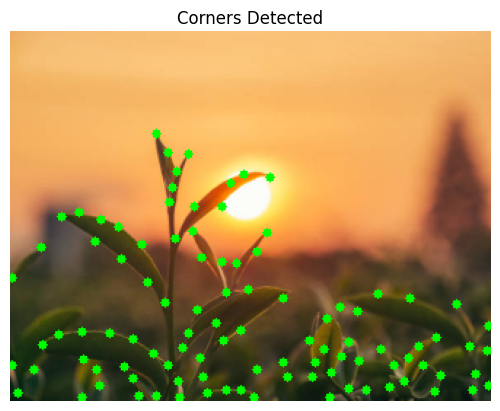

In [14]:
corners = np.intp(corners)  # Convert to integer coords
for corner in corners:
    x, y = corner.ravel()
    cv2.circle(img, (x, y), radius=3, color=(0, 255, 0), thickness=-1)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Corners Detected')
plt.axis('off')
plt.show()

Corner Detection with Shi-Tomasi Corner Detection Method using OpenCV

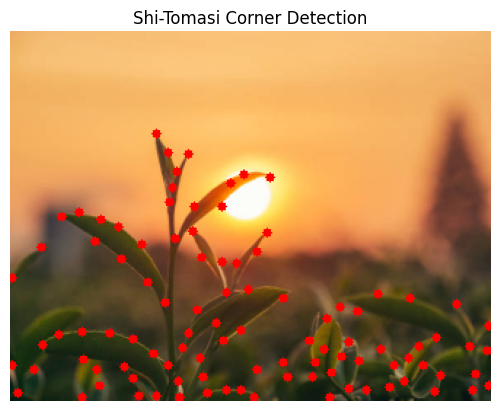

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('images\image.png')

gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

corners = cv2.goodFeaturesToTrack(gray_img, 100, 0.01, 10)
corners = np.int32(corners)

for i in corners:
    x, y = i.ravel()
    cv2.circle(img, (x, y), 3, (0, 0, 255), -1)  

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title('Shi-Tomasi Corner Detection')
plt.axis('off')  
plt.show()

Python | Corner detection with Harris Corner Detection method using OpenCV

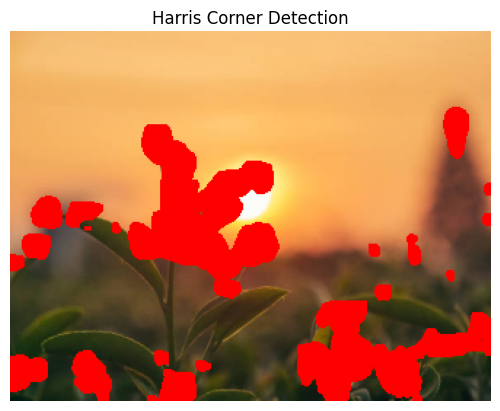

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "images\image.png"  
image = cv2.imread(image_path)

operatedImage = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
operatedImage = np.float32(operatedImage)


dest = cv2.cornerHarris(operatedImage, 17, 21, 0.01)
dest = cv2.dilate(dest, None)

image[dest > 0.01 * dest.max()] = [0, 0, 255]
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title('Harris Corner Detection')
plt.axis('off')  
plt.show()

Find Circles and Ellipses in an Image using OpenCV | Python

In [10]:
import cv2
import numpy as np

# Load image
image = cv2.imread('images\image.png', 0)

# Set our filtering parameters
# Initialize parameter setting using cv2.SimpleBlobDetector
params = cv2.SimpleBlobDetector_Params()

# Set Area filtering parameters
params.filterByArea = True
params.minArea = 100

# Set Circularity filtering parameters
params.filterByCircularity = True 
params.minCircularity = 0.9

# Set Convexity filtering parameters
params.filterByConvexity = True
params.minConvexity = 0.2
    
# Set inertia filtering parameters
params.filterByInertia = True
params.minInertiaRatio = 0.01

# Create a detector with the parameters
detector = cv2.SimpleBlobDetector_create(params)
    
# Detect blobs
keypoints = detector.detect(image)

# Draw blobs on our image as red circles
blank = np.zeros((1, 1)) 
blobs = cv2.drawKeypoints(image, keypoints, blank, (0, 0, 255),
                          cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

number_of_blobs = len(keypoints)
text = "Number of Circular Blobs: " + str(len(keypoints))
cv2.putText(blobs, text, (20, 550),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 100, 255), 2)

# Show blobs
cv2.imshow("Filtering Circular Blobs Only", blobs)
cv2.waitKey(0)
cv2.destroyAllWindows()

Python | Smile detection using OpenCV

In [11]:
import cv2
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades +'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades +'haarcascade_eye.xml')
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades +'haarcascade_smile.xml')

In [12]:
cap = cv2.VideoCapture(0)

In [ ]:
import cv2

# Load Haar Cascades
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')

# Start webcam
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    if not ret:
        print("Failed to grab frame.")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255,0,0), 2)

        roi_gray = gray[y:y+h, x:x+w]

        smiles = smile_cascade.detectMultiScale(
            roi_gray,
            scaleFactor=1.8,
            minNeighbors=20,
            minSize=(25,25)
        )

        for (sx, sy, sw, sh) in smiles:
            cv2.rectangle(frame,
                          (x+sx, y+sy),
                          (x+sx+sw, y+sy+sh),
                          (0,255,0), 2)

    cv2.imshow("Smile Detection", frame)

    # Press Q to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Feature extraction and image classification using OpenCV

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import cv2

image = cv2.imread(r'images\image.png')   # use r for Windows path
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("Done ✅")


Done ✅


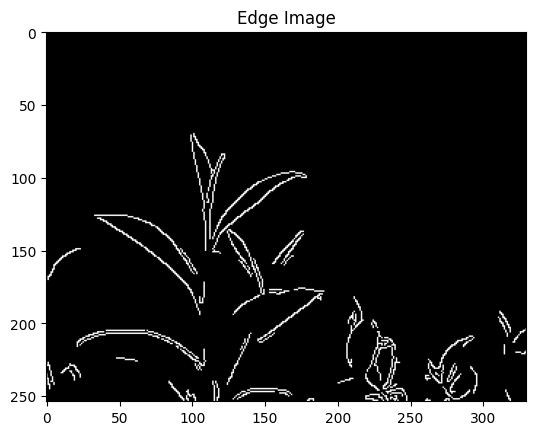

In [5]:
import cv2
import matplotlib.pyplot as plt
edges = cv2.Canny(gray_image, 100, 200)
plt.imshow(edges, cmap='gray')
plt.title('Edge Image')
plt.show()

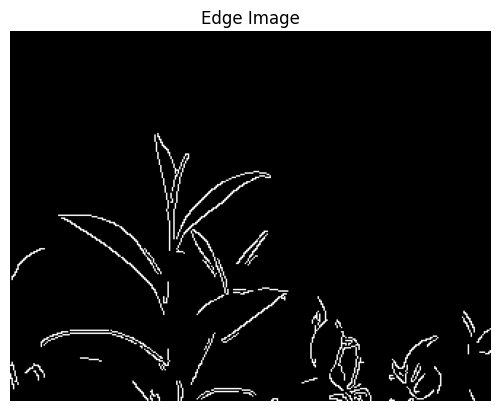

In [3]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread(r'images\image.png')

if image is None:
    print("❌ Image not found")
else:
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray_image, 100, 200)

    plt.imshow(edges, cmap='gray')
    plt.title('Edge Image')
    plt.axis('off')
    plt.show()


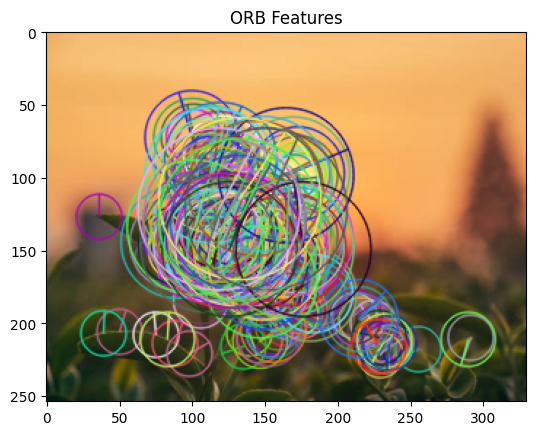

In [4]:
orb = cv2.ORB_create()
keypoints, descriptors = orb.detectAndCompute(gray_image, None)
image_with_orb = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(cv2.cvtColor(image_with_orb, cv2.COLOR_BGR2RGB))
plt.title('ORB Features')
plt.show()

In [21]:
import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

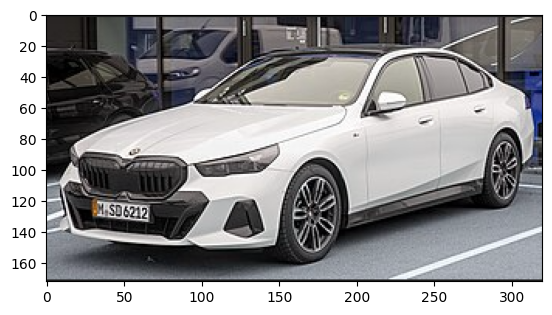

In [23]:
img = cv2.imread('images\image1.png')
plt.imshow(img)

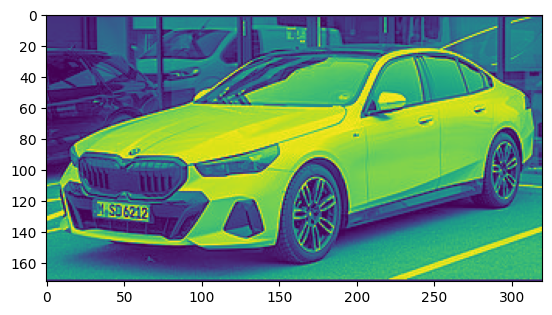

In [8]:
#Converting the image to gray
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray.shape
plt.imshow(gray)

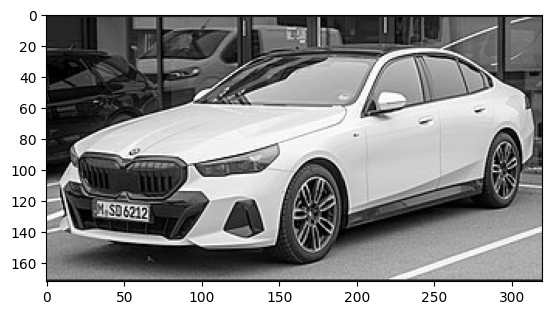

In [9]:
plt.imshow(gray, cmap='gray')

In [17]:
import cv2

image = cv2.imread(r'images\face.png')

if image is None:
    print("❌ Image not found")
    exit()

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

faces = face_cascade.detectMultiScale(gray, 1.3, 5)

print("Faces detected:", len(faces))


Faces detected: 1


In [18]:
(x,y,w,h) = faces[0]
x,y,w,h

(np.int32(39), np.int32(27), np.int32(106), np.int32(106))

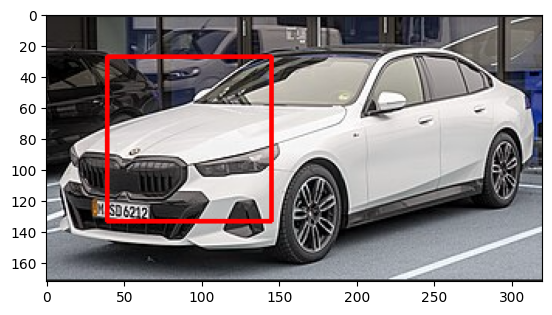

In [19]:
face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)

In [9]:
import cv2
cv2.destroyAllWindows()
for (x,y,w,h) in faces:
    face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = face_img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)
        

plt.figure()
plt.imshow(face_img, cmap='gray')
plt.show()

NameError: name 'faces' is not defined

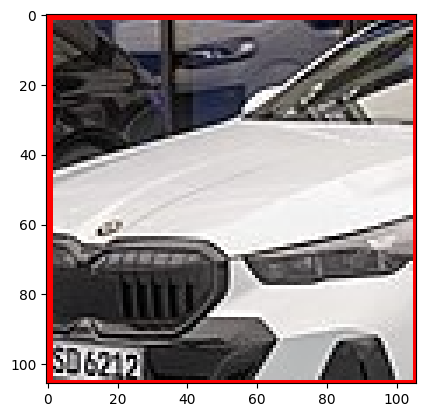

In [25]:
#Plotting the cropped Image
%matplotlib inline
plt.imshow(roi_color, cmap='gray')
plt.show()

In [26]:
cropped_img = np.array(roi_color)
cropped_img.shape

(106, 106, 3)

In [27]:
import numpy as np
import pywt
import cv2    

def w2d(img, mode='haar', level=1):
    imArray = img
    #Datatype conversions
    #convert to grayscale
    imArray = cv2.cvtColor( imArray,cv2.COLOR_RGB2GRAY )
    #convert to float
    imArray =  np.float32(imArray)   
    imArray /= 255;
    # compute coefficients 
    coeffs=pywt.wavedec2(imArray, mode, level=level)

    #Process Coefficients
    coeffs_H=list(coeffs)  
    coeffs_H[0] *= 0;  

    # reconstruction
    imArray_H=pywt.waverec2(coeffs_H, mode);
    imArray_H *= 255;
    imArray_H =  np.uint8(imArray_H)

    return imArray_H

ModuleNotFoundError: No module named 'pywt'

In [28]:
im_har = w2d(cropped_img,'db1',5)
plt.imshow(im_har, cmap='gray')

NameError: name 'w2d' is not defined

TypeError: Image data of dtype object cannot be converted to float

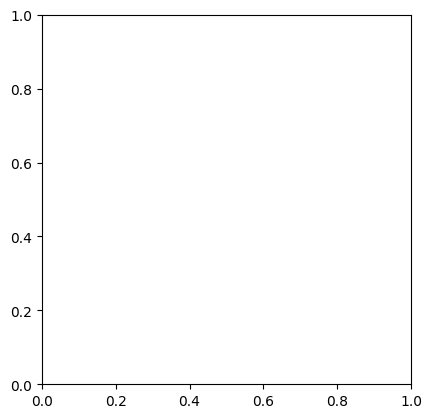

In [29]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >= 2:
            return roi_color
          
original_image = cv2.imread('images\ms_dhoni\dhoni.jpg')
plt.imshow(original_image)

In [ ]:
cropped_image = get_cropped_image_if_2_eyes('images\ms_dhoni\dhoni.jpg')
plt.imshow(cropped_image)

In [ ]:
path_to_data = "./images/"
path_to_cr_data = "./images/cropped/"

import os
img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)
img_dirs

In [ ]:
import shutil
if os.path.exists(path_to_cr_data):
     shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [ ]:
cropped_image_dirs = []
celebrity_file_names_dict = {}

for img_dir in img_dirs:
    count = 1
    celebrity_name = img_dir.split('/')[-1]
    print(celebrity_name)
    
    celebrity_file_names_dict[celebrity_name] = []
    
    for entry in os.scandir(img_dir):
        roi_color = get_cropped_image_if_2_eyes(entry.path)
        if roi_color is not None:
            cropped_folder = path_to_cr_data + celebrity_name
            if not os.path.exists(cropped_folder):
                os.makedirs(cropped_folder)
                cropped_image_dirs.append(cropped_folder)
                print("Generating cropped images in folder: ",cropped_folder)
                
            cropped_file_name = celebrity_name + str(count) + ".png"
            cropped_file_path = cropped_folder + "/" + cropped_file_name 
            
            cv2.imwrite(cropped_file_path, roi_color)
            celebrity_file_names_dict[celebrity_name].append(cropped_file_path)
            count += 1

In [ ]:
celebrity_file_names_dict = {}
for img_dir in cropped_image_dirs:
    celebrity_name = img_dir.split('/')[-1]
    file_list = []
    for entry in os.scandir(img_dir):
        file_list.append(entry.path)
    celebrity_file_names_dict[celebrity_name] = file_list
celebrity_file_names_dict

In [ ]:
class_dict = {}
count = 0
for celebrity_name in celebrity_file_names_dict.keys():
    class_dict[celebrity_name] = count
    count = count + 1
class_dict

In [ ]:
X, y = [], []
for celebrity_name, training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        if img is None:
            continue
        scalled_raw_img = cv2.resize(img, (32, 32))
        img_har = w2d(img,'db1',5)
        scalled_img_har = cv2.resize(img_har, (32, 32))
        combined_img = np.vstack((scalled_raw_img.reshape(32*32*3,1),scalled_img_har.reshape(32*32,1)))
        X.append(combined_img)
        y.append(class_dict[celebrity_name])

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel = 'rbf', C = 10))])
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

In [ ]:
print(classification_report(y_test, pipe.predict(X_test)))